In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [2]:
# 1. Загрузите изображение в оттенках серого sar_1_gray.jpg. 
# 2. постройте гистограмму
# 3. реализуйте алгоритм гамма коррекции с параметром гамма <1, >1.
# 4. Сравните исходное изображение, скорректированное при помощи гамма-фильтра. MSE, SSIM.
# 5. реализуйте алгоритм статистической цветокоррекции на основе статистики eq_gray.
# 6. Протестируйте работу алгоритмов пороговой фильтрации с различными параметрами.
# Для каждого решения - напечатайте результат


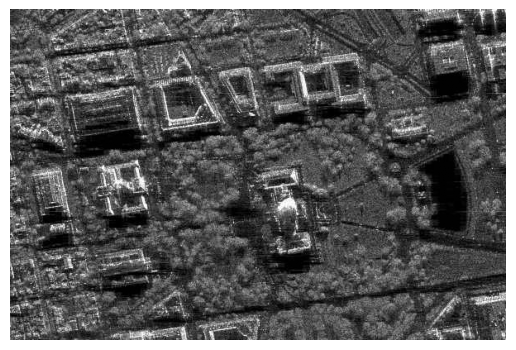

In [3]:
# Пункт 1. Загрузка изображения в оттенках серого

gray = cv2.imread('sar_1_gray.jpg', cv2.IMREAD_GRAYSCALE)

plt.imshow(gray, cmap='gray')
plt.axis('off')
plt.show()

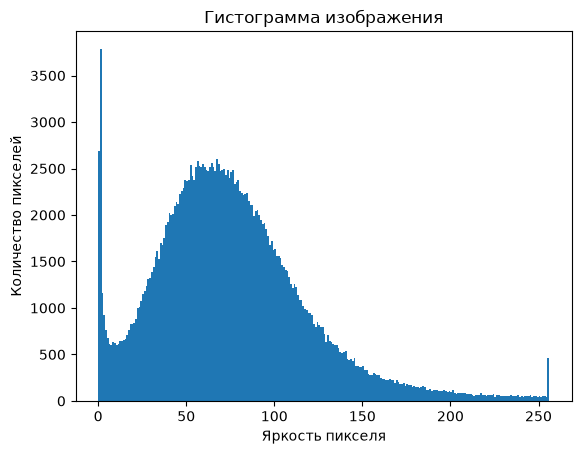

In [4]:
# Пункт 2. Гистограмма изображения

plt.hist(gray.ravel(), bins=256, range=[0, 256])
plt.xlabel('Яркость пикселя')
plt.ylabel('Количество пикселей')
plt.title('Гистограмма изображения')
plt.show()

In [5]:
# Пункт 3. Реализация гамма-коррекции

def gamma_correction(image, gamma):
    normalized = image / 255.0
    corrected = np.power(normalized, gamma)
    corrected = np.uint8(corrected * 255)
    return corrected

gamma_less_1 = gamma_correction(gray, 0.5)
gamma_more_1 = gamma_correction(gray, 2.0)

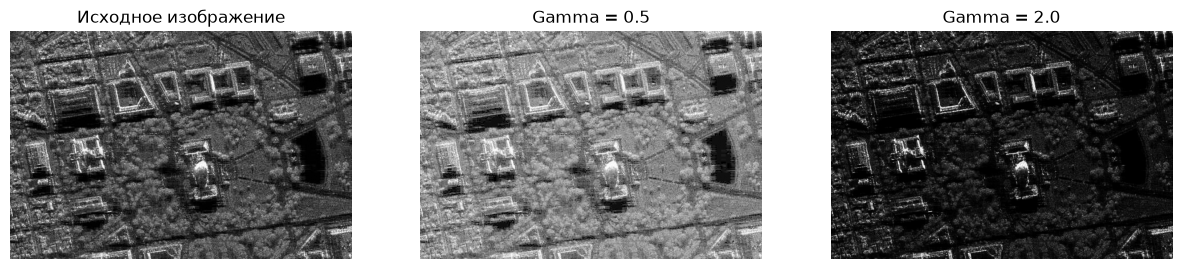

In [6]:
# Вывод результатов гамма-коррекции

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(gamma_less_1, cmap='gray')
plt.title('Gamma = 0.5')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(gamma_more_1, cmap='gray')
plt.title('Gamma = 2.0')
plt.axis('off')

plt.show()

In [7]:
# Пункт 4. Сравнение изображений по MSE и SSIM

from skimage.metrics import mean_squared_error, structural_similarity

mse_gamma_05 = mean_squared_error(gray, gamma_less_1)
ssim_gamma_05 = structural_similarity(gray, gamma_less_1)

mse_gamma_20 = mean_squared_error(gray, gamma_more_1)
ssim_gamma_20 = structural_similarity(gray, gamma_more_1)

print('Gamma = 0.5')
print('MSE:', mse_gamma_05)
print('SSIM:', ssim_gamma_05)

print()

print('Gamma = 2.0')
print('MSE:', mse_gamma_20)
print('SSIM:', ssim_gamma_20)


Gamma = 0.5
MSE: 3250.429145833333
SSIM: 0.7875008686792752

Gamma = 2.0
MSE: 2383.7636375
SSIM: 0.5270459922820343


In [8]:
# Собственная реализация эквализации гистограммы

def histogram_equalization(image):
    hist = np.bincount(image.ravel(), minlength=256)

    cdf = hist.cumsum()

    cdf_min = cdf[cdf > 0][0]

    equalized = (cdf - cdf_min) / (image.size - cdf_min) * 255
    equalized = np.clip(equalized, 0, 255).astype(np.uint8)

    return equalized[image]


eq_gray = histogram_equalization(gray)

In [9]:
# Пункт 5. Статистическая цветокоррекция

mean_gray = np.mean(gray)
std_gray = np.std(gray)

mean_eq = np.mean(eq_gray)
std_eq = np.std(eq_gray)

stat_corrected = (gray - mean_gray) * (std_eq / std_gray) + mean_eq

stat_corrected = np.clip(stat_corrected, 0, 255)
stat_corrected = np.uint8(stat_corrected)

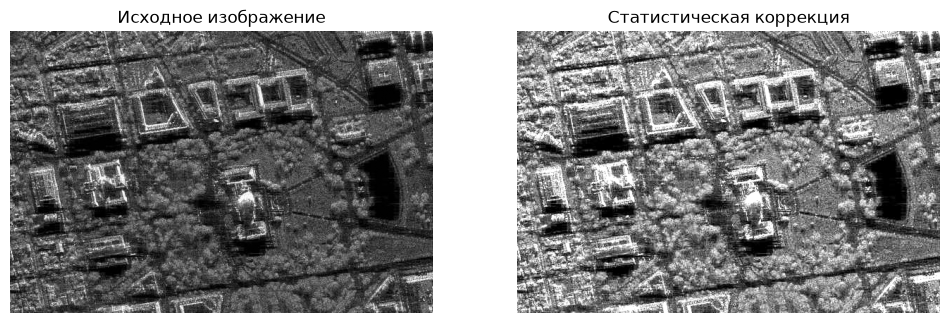

In [10]:
# Вывод результата статистической цветокоррекции

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Исходное изображение')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(stat_corrected, cmap='gray')
plt.title('Статистическая коррекция')
plt.axis('off')

plt.show()

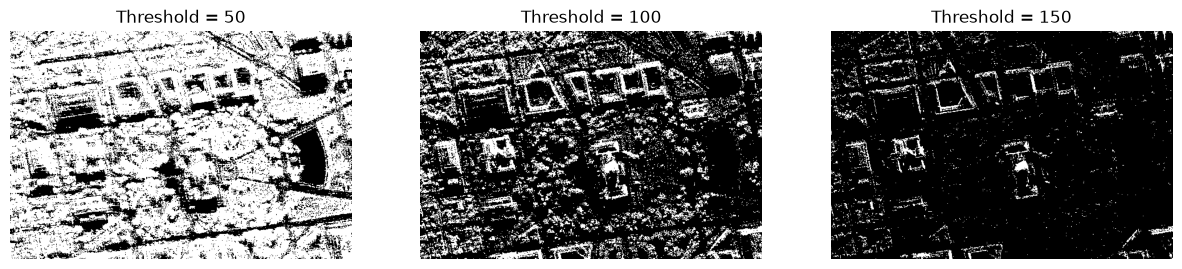

In [11]:
# Пункт 6. Пороговая фильтрация с разными параметрами

_, thresh_50 = cv2.threshold(gray, 50, 255, cv2.THRESH_BINARY)
_, thresh_100 = cv2.threshold(gray, 100, 255, cv2.THRESH_BINARY)
_, thresh_150 = cv2.threshold(gray, 150, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(thresh_50, cmap='gray')
plt.title('Threshold = 50')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(thresh_100, cmap='gray')
plt.title('Threshold = 100')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(thresh_150, cmap='gray')
plt.title('Threshold = 150')
plt.axis('off')

plt.show()